In [501]:
import torch
from torch_scatter import scatter_mean
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import networkx as nx
import os
import pickle
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))

from methods import mcmc_community_delays, mmca_community_delays
from methods.utils import graph_dynamic_delays

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [502]:
# ---------------初始数据-----------------------------

# 导入默认参数
file_path = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'parameters/community_data_1.pkl')
with open(file_path, 'rb') as f:
    init_data = pickle.load(f)

epi_paras = torch.tensor(init_data['epi_paras'], dtype=torch.float32).to(device)
soc_paras = torch.tensor(init_data['soc_paras'], dtype=torch.float32).to(device)
features_state = torch.tensor(init_data['init_state'], dtype=torch.float32).to(device)
P_rows, P_cols = init_data['P_matrix'].nonzero()
P_edge_index = torch.tensor(np.array([P_rows, P_cols]), dtype=torch.long).to(device)
communities = init_data['communities']
P_community = init_data['P_community']
P_G = init_data['P_G']

I_rows, I_cols = init_data['I_matrix'].nonzero()
I_edge_index = torch.tensor(np.array([I_rows, I_cols]), dtype=torch.long).to(device)

# # # ---------------初始数据-----------------------------
node_num =  features_state.shape[0]
time_scale = 1000

In [503]:
para_len = 100
soc_paras_mcmc = soc_paras.unsqueeze(0).repeat(para_len, 1)
epi_paras_mcmc = epi_paras.unsqueeze(0).repeat(para_len, 1, 1) 
features_state_tensor_mcmc = features_state.unsqueeze(0).repeat(para_len, 1, 1).to(device)
delays = 0
mcmc = mcmc_community_delays.MCMC(para_len, device)
mcmc_features_times, _, _ = graph_dynamic_delays(time_scale, mcmc, features_state_tensor_mcmc.clone(), epi_paras_mcmc,soc_paras_mcmc, P_edge_index, I_edge_index, communities, device, delays)
torch.save(mcmc_features_times, f'./data/mcmc_features_times_{delays}.pt')

In [504]:
para_len = 1
soc_paras_mmca = soc_paras.unsqueeze(0).repeat(para_len, 1)
epi_paras_mmca = epi_paras.unsqueeze(0).repeat(para_len, 1, 1) 
features_state_tensor_mmca = features_state.unsqueeze(0).repeat(para_len, 1, 1).to(device)

mmca = mmca_community_delays.MMCA(device)
mmca_features_times, _,_ = graph_dynamic_delays(time_scale, mmca, features_state_tensor_mmca.clone(), epi_paras_mmca,soc_paras_mmca, P_edge_index, I_edge_index, communities, device, delays)

e:\博士期间论文\信息物理社会项目\三层网络动力学\project0430\codes\Dynamics\methods\mmca_community_delays.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  communities = torch.tensor(communities, device=self.device)


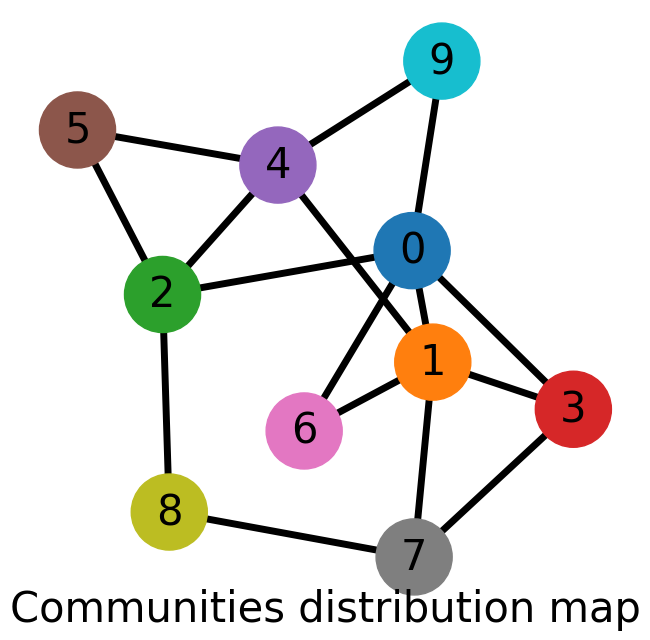

In [505]:
# 可视化社区图
plt.figure(figsize=(6, 6))
# community_pos = nx.spring_layout(community_graph, seed=1)  # 社区图的位置
community_pos = nx.kamada_kawai_layout(P_community)
nx.draw(P_community, community_pos, node_color=range(len(P_community)), cmap='tab10', node_size=3000, width=5,
         with_labels=True, font_size=30, font_color='black' )
plt.text(0.5, 0, f"Communities distribution map", 
         fontsize=30, ha='center', va='center', transform=plt.gca().transAxes)
plt.show()
# plt.savefig(f'../figs/Diffusion/Community1/c0.svg', bbox_inches='tight')
# plt.savefig(f'../figs/Diffusion/Community1/c0.png', dpi=600, bbox_inches='tight')


In [506]:
# # 根据社区图的位置为节点图分配位置
# node_pos = {}
# for node, community in enumerate(communities):
#     # 在社区位置的基础上添加随机偏移
#     offset = np.random.normal(0.1, 0.13, size=2)  # 随机偏移
#     node_pos[node] = community_pos[community] + offset
# # 为每个社区计算布局
from collections import defaultdict
node_pos = {}
community_nodes = defaultdict(list)
# 将节点按社区分组
for node, community in enumerate(communities):
    community_nodes[community].append(node)
# 为每个社区计算布局
for community, nodes in community_nodes.items():
    subgraph = P_G.subgraph(nodes)  # 提取社区子图
    subgraph_pos = nx.spring_layout(subgraph, k=0.5, iterations=100)  # 社区内布局
    if community == 7:
        k=0.5
    else:
        k=0.5
    for node in nodes:
        node_pos[node] = k*subgraph_pos[node] + community_pos[community]  # 映射到全局布局


c:\Users\95406\.conda\envs\stablebaseline3\Lib\site-packages\networkx\drawing\nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


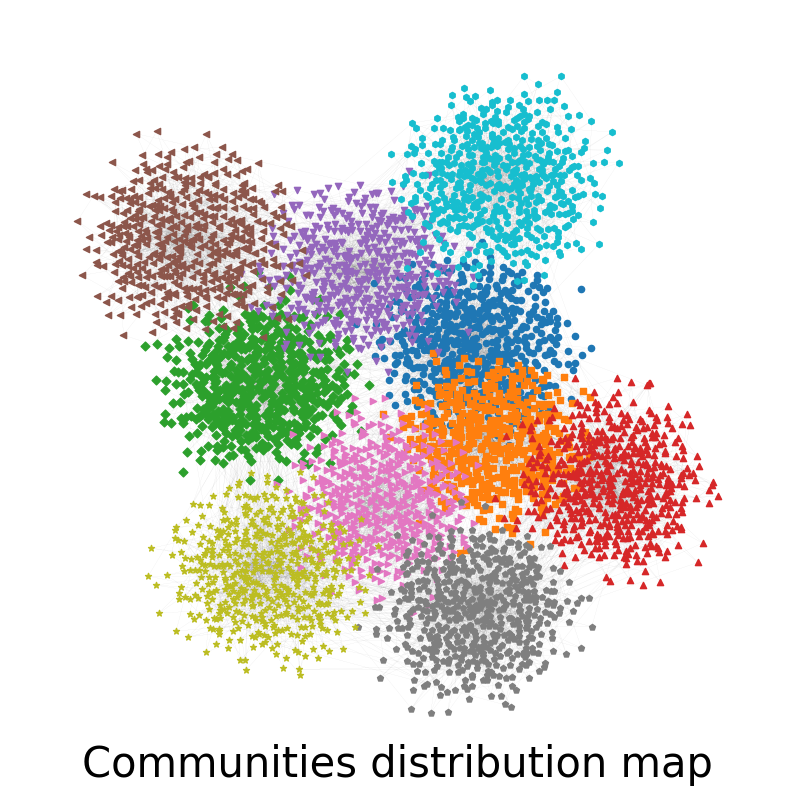

In [507]:
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'x', '+', 'X', 'd']
# 可视化生成的节点图
plt.figure(figsize=(10, 10))
# 绘制节点，为每个社区分配不同的 marker
for i, community in enumerate(set(communities)):
    nodes_in_community = [node for node, comm in zip(P_G.nodes(), communities) if comm == community]
    nx.draw_networkx_nodes(P_G, node_pos, nodelist=nodes_in_community, 
                           node_color=plt.cm.tab10(i), node_size=20, 
                           node_shape=markers[i % len(markers)]) 
nx.draw_networkx_edges(P_G, node_pos, width=0.015)
# nx.draw(P_G, node_pos, node_color=communities, cmap='tab10', node_size=20, width=0.03)
plt.text(0.5, 0.02, f"Communities distribution map", 
         fontsize=30, ha='center', va='center', transform=plt.gca().transAxes)
legend_elements = [Line2D([0], [0], marker=markers[i % len(markers)], color='w', label=f'Com {i}', 
                          markerfacecolor=plt.cm.tab10(i), markersize=10) for i in range(len(set(communities)))]
# plt.legend(handles=legend_elements, loc='upper right',fontsize=15)
plt.axis('off')
plt.show()
# plt.savefig(f'../figs/Diffusion/Community1/c1.svg', bbox_inches='tight')
# plt.savefig(f'../figs/Diffusion/Community1/c1.png', dpi=600, bbox_inches='tight')

In [508]:
time_index = 2
features_mcmc = mcmc_features_times.squeeze(0)[time_index,...]
features_mmca = mmca_features_times.squeeze(0)[time_index,...]

communities_cpu = torch.tensor(communities)
communities_features_mcmc = scatter_mean(torch.sum(features_mcmc[:,[2,3,4]],dim=1), communities_cpu, dim=0) 
mcmc_mean = torch.mean(features_mcmc[:, [2, 3, 4]].sum(dim=1)).unsqueeze(0)
communities_features_mcmc = torch.cat((communities_features_mcmc, mcmc_mean))

communities_features_mmca = scatter_mean(torch.sum(features_mmca[:,[2,3,4]],dim=1), communities_cpu, dim=0) 
mmca_mean = torch.mean(features_mmca[:, [2, 3, 4]].sum(dim=1)).unsqueeze(0)
communities_features_mmca = torch.cat((communities_features_mmca, mmca_mean))
print(communities_features_mcmc)
print(communities_features_mmca)

tensor([0.3086, 0.0501, 0.0354, 0.0568, 0.0172, 0.0044, 0.0608, 0.0133, 0.0064,
        0.0624, 0.0629])
tensor([0.3348, 0.0741, 0.0480, 0.0867, 0.0213, 0.0054, 0.0674, 0.0190, 0.0086,
        0.0736, 0.0754])


tensor(0.0629)


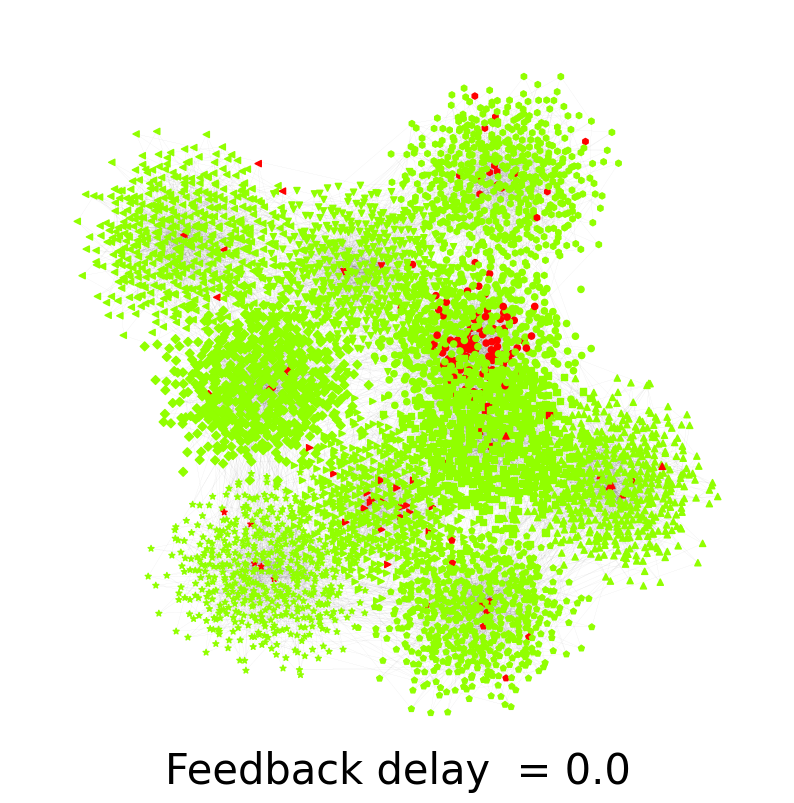

In [509]:
# custom_colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF']
custom_colors = ["#91FF00",'#FF0000']
custom_cmap = mcolors.ListedColormap(custom_colors)
# 可视化生成的节点图
node_color = torch.sum(features_mcmc[:,[2,3,4]],dim=1)
print(torch.mean(node_color))
plt.figure(figsize=(10, 10))
# 绘制节点，为每个社区分配不同的 marker
for i, community in enumerate(set(communities)):
    nodes_in_community = [node for node, comm in zip(P_G.nodes(), communities) if comm == community]
    nx.draw_networkx_nodes(P_G, node_pos, nodelist=nodes_in_community, 
                           node_color=node_color[nodes_in_community], cmap=custom_cmap, node_size=20, 
                           node_shape=markers[i % len(markers)]) 
nx.draw_networkx_edges(P_G, node_pos, width=0.015)
# nx.draw(P_G, node_pos, node_color=node_color, cmap=custom_cmap, node_size=20, width=0.03)
plt.text(0.5, 0.01, f"Feedback delay  = {delays/10}", 
         fontsize=30, ha='center', va='center', transform=plt.gca().transAxes)
# plt.title("Community-based BA Model with Community Layout")
plt.axis('off')
# plt.show()
plt.savefig(f'../figs/TimeDelays/t{time_index}_{delays}.svg', bbox_inches='tight')
plt.savefig(f'../figs/TimeDelays/t{time_index}_{delays}.png', dpi=600, bbox_inches='tight')

In [510]:
# Load data for different delay values
delay_values = [0, 5, 10, 15, 20]
time_index = 2
mcmc_communities_data = []
for delay in delay_values:
    mcmc_file = f'./data/mcmc_features_times_{delay}.pt'
    mcmc_features = torch.load(mcmc_file)
    communities_cpu = torch.tensor(communities)
    communities_features_mcmc = scatter_mean(torch.sum(mcmc_features[...,[2,3,4]],dim=2), communities_cpu, dim=1) 
    mcmc_communities_data.append(communities_features_mcmc)

time2_community_0 = [xx[2,0] for xx in mcmc_communities_data]
time2_community_9 = [xx[2,9] for xx in mcmc_communities_data]

C:\Users\95406\AppData\Local\Temp\ipykernel_26936\2025661503.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mcmc_features = torch.load(mcmc_file)


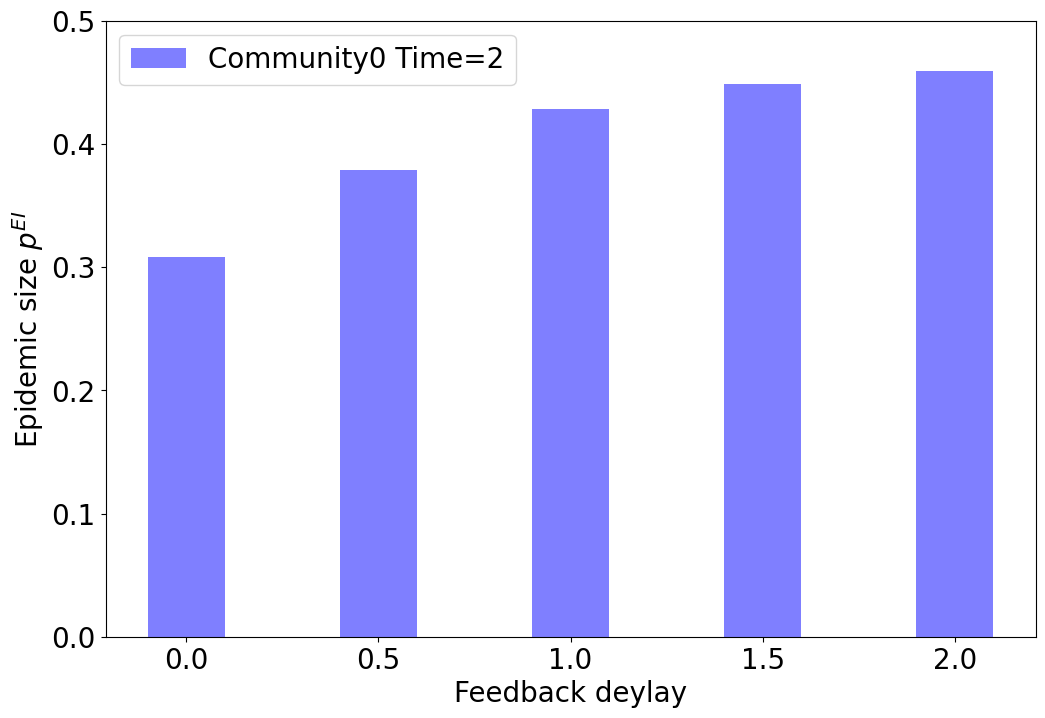

In [511]:
# Create figure for bar plot
plt.figure(figsize=(12, 8))
width = 0.05  # width of the bars

# Set x positions for bars
x = np.arange(len(delay_values))/10
x_labels = [str(d) for d in [0.0, 0.5, 1.0, 1.5, 2.0]]

# Plot bars for each community
plt.bar(x_labels , time2_community_0, width=0.4, color='blue', alpha=0.5, label='Community0 Time=2', align='center')
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feedback deylay', fontsize=20)
plt.ylim(0, 0.5) 
plt.ylabel(r'Epidemic size $p^{EI}$', fontsize=20)
plt.legend(fontsize=20)

# Save the figure
plt.savefig(f'../figs/TimeDelays/Community0Time=2.svg', bbox_inches='tight')
plt.savefig(f'../figs/TimeDelays/Community0Time=2.png', dpi=600, bbox_inches='tight')
plt.show()

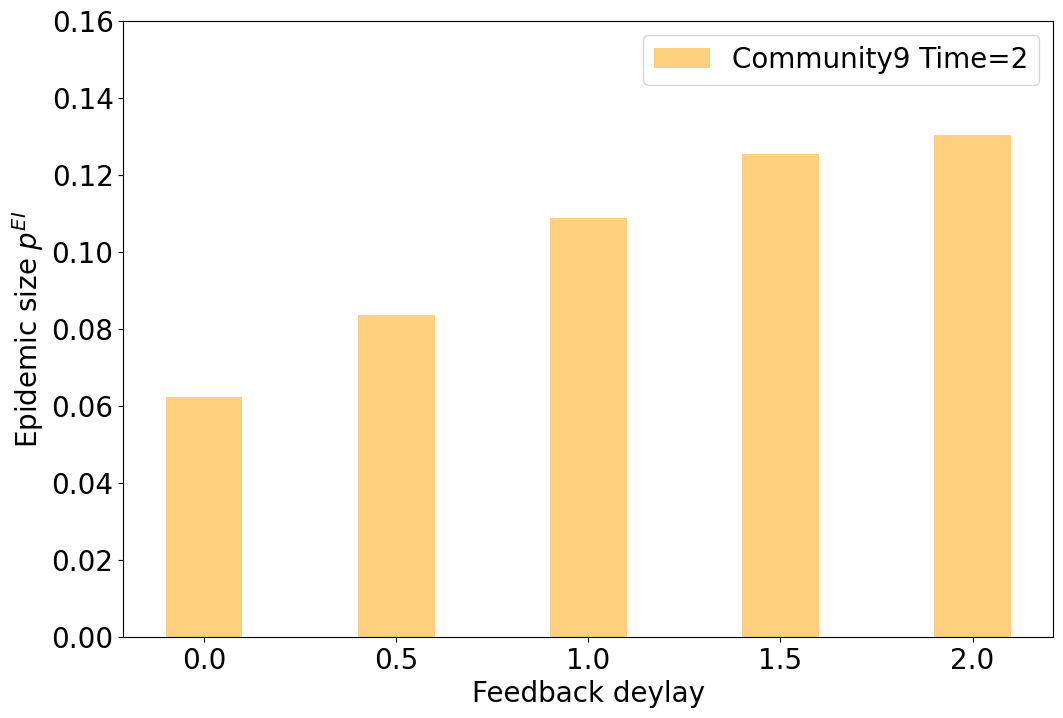

In [512]:
# Create figure for bar plot
plt.figure(figsize=(12, 8))
width = 0.05  # width of the bars

# Set x positions for bars
x = np.arange(len(delay_values))/10
x_labels = [str(d) for d in [0.0, 0.5, 1.0, 1.5, 2.0]]

# Plot bars for each community
plt.bar(x_labels , time2_community_9, width=0.4, color='orange', alpha=0.5, label='Community9 Time=2', align='center')
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Feedback deylay', fontsize=20)
plt.ylim(0, 0.16) 
plt.ylabel(r'Epidemic size $p^{EI}$', fontsize=20)
plt.legend(fontsize=20)

# Save the figure
plt.savefig(f'../figs/TimeDelays/Community9Time=2.svg', bbox_inches='tight')
plt.savefig(f'../figs/TimeDelays/Community9Time=2.png', dpi=600, bbox_inches='tight')
plt.show()

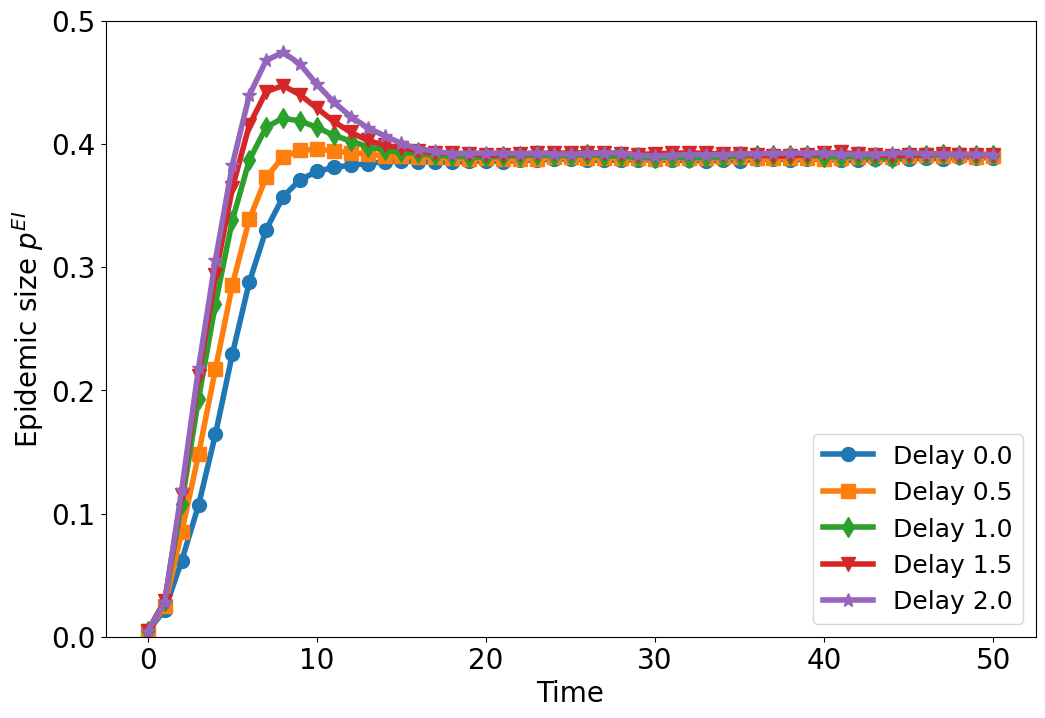

In [513]:
time_scale = torch.arange(mcmc_communities_data[0][0:51,:].shape[0])

# Create a figure with appropriate size
plt.figure(figsize=(12, 8))

# Plot line graphs for different communities
plt.plot(time_scale, mcmc_communities_data[0][0:51,:].mean(dim=1), 'o-', linewidth=4, markersize=10, label='Delay 0.0')
plt.plot(time_scale, mcmc_communities_data[1][0:51,:].mean(dim=1), 's-', linewidth=4, markersize=10, label='Delay 0.5')
plt.plot(time_scale, mcmc_communities_data[2][0:51,:].mean(dim=1), 'd-', linewidth=4, markersize=10, label='Delay 1.0')
plt.plot(time_scale, mcmc_communities_data[3][0:51,:].mean(dim=1), 'v-', linewidth=4, markersize=10, label='Delay 1.5')
plt.plot(time_scale, mcmc_communities_data[4][0:51,:].mean(dim=1), '*-', linewidth=4, markersize=10, label='Delay 2.0')

# Set y-axis limits from 0 to 0.5
plt.ylim(0, 0.5)
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time', fontsize=20)
plt.ylabel(r'Epidemic size $p^{EI}$', fontsize=20)
plt.legend(fontsize=18)

# Save the figure
plt.savefig('../figs/TimeDelays/delay_time.svg', bbox_inches='tight')
plt.savefig('../figs/TimeDelays/delay_time.png', dpi=600, bbox_inches='tight')
# plt.show()